<a href="https://colab.research.google.com/github/25ds3000042/ML-Algorithms-Using-NumPy/blob/main/T2_2026_MLT_Workshop_Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLT Workshop — Day 3
## K-Means Clustering, Gradient Descent, Linear Regression

---
## Part 0 — Setup

In [1]:

import numpy as np

import matplotlib.pyplot as plt

np.random.seed(42)


---
# Part 1 — K-Means Clustering

The algorithm in four lines:

1. Pick `k` starting centroids.
2. **Assign step** — give every point the label of its nearest centroid.
3. **Update step** — move each centroid to the mean of its assigned points.
4. Repeat 2 and 3 until nothing changes.

We will write steps 2 and 3 as two separate functions, then join them in a loop
that draws a picture after every single iteration.

## 1.1 — Make the data

We build the data ourselves, so we already know the right answer. Three round
blobs: take random noise, shift it to a chosen centre.

In [2]:
true_centres = np.array([
    [2.0, 2.0],   # bottom left
    [8.0, 3.0],   # bottom right
    [5.0, 9.0],   # top middle
])

# How many points go inside each blob.
points_per_cluster = 60

# An empty Python list. We add one block of points per blob into it.
all_points = []

# Looping over a 2-D array gives one ROW at a time,
# so "centre" is an array of 2 numbers, for example [2.0, 2.0].
for centre in true_centres:
    noise = np.random.randn(points_per_cluster, 2)
    cluster_points = centre + 0.8 * noise
    all_points.append(cluster_points)

# np.vstack means "vertical stack" - glue arrays on top of each other.
# Three blocks of (60, 2) become one array of (180, 2).
X = np.vstack(all_points)

print("Shape of X:", X.shape)
print("So:", X.shape[0], "points, each described by", X.shape[1], "numbers.")
print()
print("The first 3 points:")
print(X[:3])

Shape of X: (180, 2)
So: 180 points, each described by 2 numbers.

The first 3 points:
[[2.39737132 1.88938856]
 [2.51815083 3.21842389]
 [1.8126773  1.81269043]]


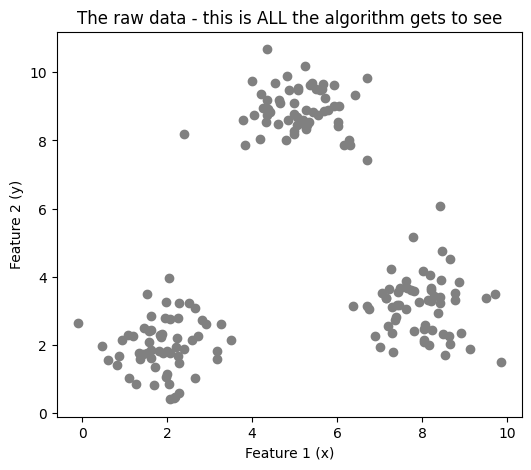

In [3]:


# plt.figure() opens a blank canvas. figsize is (width, height) in inches.
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], color="grey")
plt.xlabel("Feature 1 (x)")
plt.ylabel("Feature 2 (y)")
plt.title("The raw data - this is ALL the algorithm gets to see")
plt.show()

## 1.3 — Measuring distance

K-means needs to know which centroid is nearest, so it needs a distance. We use
the ordinary straight-line (Euclidean) distance, written in four steps so the
formula is visible in the code.

In [4]:

def euclidean_distance(point_a, point_b):

    difference = point_a - point_b
    squared = difference ** 2
    total = np.sum(squared)
    return np.sqrt(total)


## 1.4 — Choosing the starting centroids

The simplest sensible choice: pick `k` of the actual data points at random.

In [5]:
def initialise_centroids(X, k):
    n_points = X.shape[0]
    random_indices = np.random.choice(n_points, size=k, replace=False)
    chosen_points = X[random_indices]
    return chosen_points.copy()


## 1.5 — The assign step

For each point: measure the distance to every centroid, keep the index of the
smallest. Two nested loops, exactly as written on paper.

In [6]:

def assign_points_to_centroids(X, centroids):

    n_points = X.shape[0]      # how many points
    k = centroids.shape[0]     # how many centroids

    # np.zeros(n) makes an array of n zeros.
    # dtype=int forces whole numbers, because a label must be 0, 1 or 2,
    labels = np.zeros(n_points, dtype=int)

    # OUTER LOOP: one data point at a time.
    # range(n) produces 0, 1, 2, ..., n-1
    for i in range(n_points):

        # A small scratch array: this point's distance to each centroid.
        distances = np.zeros(k)

        # INNER LOOP: one centroid at a time.
        for j in range(k):
            # X[i] is point number i. centroids[j] is centroid number j.
            distances[j] = euclidean_distance(X[i], centroids[j])

        # np.argmin gives the POSITION of the smallest value.
        # If distances = [7.2, 1.4, 5.9] then argmin returns 1.
        # That position IS the cluster label.
        labels[i] = np.argmin(distances)

    return labels


## 1.6 — The update step

Move each centroid to the average position of the points assigned to it. This is
the only place the word "means" in *k-means* actually appears.

In [7]:


def update_centroids(X, labels, k):

    n_features = X.shape[1]   # number of columns, here 2
    new_centroids = np.zeros((k, n_features))

    # One cluster at a time.
    for j in range(k):
        points_in_cluster = X[labels == j]
        new_centroids[j] = np.mean(points_in_cluster, axis=0)

    return new_centroids

## 1.7 —  plotting

We want a picture after every iteration, so we put the plotting code in its own
function and call it from inside the loop.

In [8]:

colours = ["blue", "orange", "green"]


def plot_step(X, labels, centroids, title):

    plt.figure(figsize=(6, 5))

    # Draw one cluster at a time, so each gets its own colour.
    for j in range(centroids.shape[0]):

        # Boolean masking again: keep only the points labelled j.
        cluster_points = X[labels == j]

        plt.scatter(cluster_points[:, 0],   # x coordinates of this cluster
                    cluster_points[:, 1],   # y coordinates of this cluster
                    color=colours[j],
                    label="Cluster " + str(j))

    # Now the centroids on top, drawn big and red so they stand out.
    plt.scatter(centroids[:, 0],
                centroids[:, 1],
                color="red",
                marker="X",
                s=250,              # s is the marker size
                edgecolor="black",
                label="Centroids")

    plt.xlabel("Feature 1 (x)")
    plt.ylabel("Feature 2 (y)")
    plt.title(title)
    plt.legend()
    plt.show()

plot_step(X, first_labels, starting_centroids,
          "Before any update: random centroids, points coloured by nearest one")

NameError: name 'first_labels' is not defined

## 1.8 — The k-means loop

Assign, draw, check, update — repeat. The picture is drawn **inside** the loop,
so you can scroll through the output and watch the red crosses walk into the
centres of the blobs.

In [ ]:

def run_kmeans(X, k, max_iterations=10, start_centroids=None):

    # Step 1: starting positions.
    # If the caller did not hand us any, pick k random data points as usual.
    if start_centroids is None:
        centroids = initialise_centroids(X, k)
    else:
        centroids = start_centroids.copy()

    # We compare each round's labels with the previous round's labels.
    # np.zeros(...) - 1 fills the array with -1, meaning "no previous round yet",
    # a value no real label can ever take.
    previous_labels = np.zeros(X.shape[0], dtype=int) - 1

    # max_iterations is a safety cap, so the cell can never run forever.
    for iteration in range(max_iterations):

        # Step 2: ASSIGN every point to its nearest centroid.
        labels = assign_points_to_centroids(X, centroids)

        # Step 3: DRAW what we have right now, before moving anything.
        plot_step(X, labels, centroids, "Iteration " + str(iteration))

        # Step 4: STOP if nobody changed cluster since last time.
        # np.all(...) is True only when EVERY comparison is True.
        if np.all(labels == previous_labels):
            print("No point changed cluster. The algorithm has converged.")
            break

        # Step 5: UPDATE - move each centroid to the mean of its points.
        centroids = update_centroids(X, labels, k)

        # Remember this round's labels for the comparison next time.
        previous_labels = labels

    return centroids, labels




# We start from a deliberately BAD position: the first three data points,
# which all happen to sit inside the bottom-left blob. Cramming all three
# centroids into one corner makes the algorithm work harder, so there are
# more pictures to look at and the movement is obvious.
bad_start = X[:3].copy()

final_centroids, final_labels = run_kmeans(X, k=3, start_centroids=bad_start)

print()
print("Final centroids found by the algorithm:")
print(final_centroids)
print()
print("The true centres we used to build the data:")
print(true_centres)
print()
print("The rows may be in a different order. Cluster 0 for us is not")
print("necessarily blob 0 for the data generator - the numbering is arbitrary.")
print("Only the grouping matters.")

---
# Part 2 — Gradient Descent

Before fitting any model, we practise the optimiser on a function where we can
see the whole landscape.

The update rule — the only formula you need for the rest of the day:

$$ x_{\text{new}} = x_{\text{old}} - \eta \cdot f'(x_{\text{old}}) $$

where $\eta$ (eta) is the **learning rate**. We do one dimension first, then
exactly the same rule with more than one.

## 2.1 — The function to minimise

In [ ]:
# ============================================================
# 2.1 - THE FUNCTION AND ITS DERIVATIVE
# ============================================================

# f(x) = (x - 3)^2 + 2
# A parabola with its lowest point at x = 3, where f(3) = 2.
# We already know the answer - that is the point. It lets us check whether
# gradient descent finds what we know to be true.
def f(x):
    return (x - 3.0) ** 2 + 2.0


# The derivative, worked out by hand:
#   d/dx [ (x - 3)^2 + 2 ] = 2 * (x - 3)
# The derivative tells us the SLOPE of f at a given x.
def f_prime(x):
    return 2.0 * (x - 3.0)


# ---- Check the derivative behaves sensibly ----

print("f(3) =", f(3.0), "  <- the smallest value f can take")
print()
print("Slope at x = 0:", f_prime(0.0), " negative -> the curve falls to the right")
print("Slope at x = 3:", f_prime(3.0), "  zero    -> we are at the bottom")
print("Slope at x = 6:", f_prime(6.0), "  positive -> the curve rises to the right")

# ---- Draw the curve ----

# np.linspace(start, stop, num) gives "num" evenly spaced values from start to
# stop, including both ends. Here: 200 values from -2 to 8.
x_grid = np.linspace(-2, 8, 200)

# Passing a whole array to f() applies the formula to every element at once.
y_grid = f(x_grid)

plt.figure(figsize=(6, 5))
plt.plot(x_grid, y_grid, label="f(x) = (x-3)^2 + 2")
plt.scatter([3.0], [f(3.0)], color="red", s=100, label="true minimum at x = 3")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("The hill gradient descent has to walk down")
plt.legend()
plt.show()

## 2.2 — Gradient descent in one dimension

In [ ]:


def gradient_descent_1d(start_x, learning_rate, n_steps, show_table=True):

    # Our current guess, starting wherever the caller says.
    x = start_x

    # A list recording every position we visit, starting with the first.
    path = [x]

    if show_table:
        # An f-string puts variables inside {} in a string.
        # {'x':>9} means: right-align this in a 9-character-wide column.
        print(f"{'step':>4} | {'x':>9} | {'f(x)':>9} | {'slope':>9}")
        print("-" * 42)   # "-" * 42 repeats the dash 42 times

    for step in range(n_steps):

        # STEP 1: how steep is the slope right here?
        gradient = f_prime(x)

        if show_table:
            # {x:>9.4f} means: a float, 4 decimals, in a 9-wide column.
            print(f"{step:>4} | {x:>9.4f} | {f(x):>9.4f} | {gradient:>9.4f}")


        # We move AGAINST the gradient, because the gradient points uphill.
        # That minus sign is what makes this descent instead of ascent.
        x = x - learning_rate * gradient

        # STEP 3: record where we landed.
        path.append(x)

    if show_table:
        print("-" * 42)
        print(f"{'end':>4} | {x:>9.4f} | {f(x):>9.4f} | {f_prime(x):>9.4f}")

    # Convert the list into a NumPy array so it is easy to plot later.
    return np.array(path)

path_good = gradient_descent_1d(start_x=-1.0, learning_rate=0.1, n_steps=15)

print()
print("True minimum : x = 3.0")
print("Our answer   : x =", round(path_good[-1], 4))

In [ ]:

plt.figure(figsize=(7, 5))

# The landscape (same x_grid and y_grid as before).
plt.plot(x_grid, y_grid, label="f(x)")

# The points we visited.
# path_good holds x values; f(path_good) gives their heights on the curve -
# vectorisation again, one call for all 16 points.
plt.plot(path_good,
         f(path_good),
         marker="o",
         color="red",
         label="gradient descent path")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Each red dot is one update. The steps shrink near the bottom.")
plt.legend()
plt.show()

In [ ]:


# A list of learning rates to compare.
learning_rates = [0.01, 0.1, 0.5, 1.1]

# Try each one, 15 steps, starting from the same place every time.
for lr in learning_rates:

    # show_table=False keeps the output short - we only want the final answer.
    path = gradient_descent_1d(start_x=-1.0, learning_rate=lr,
                               n_steps=15, show_table=False)

    print(f"learning rate {lr:>5}  ->  final x = {path[-1]:14.4f}")

print()
print("0.01 : far too small - after 15 steps it has barely left the start")
print("0.1  : sensible      - closing in on 3")
print("0.5  : perfect here  - lands exactly on 3 in a single step")
print("1.1  : far too big   - it overshoots and flies away from the answer")

## 2.5 — Gradient descent in more than one dimension

With two variables, the derivative becomes two derivatives —
one per variable — and we call that pair the **gradient**. We subtract
`learning_rate * gradient` from the parameters exactly as before.

Our test function:

$$ g(x, y) = (x - 3)^2 + (y + 1)^2 $$

Its lowest point is at `x = 3`, `y = -1`. The two partial derivatives are
`2(x - 3)` and `2(y + 1)`.

In [ ]:


# We store the two variables together in one NumPy array called v.
# v[0] is x and v[1] is y. Keeping them in one array is what lets the
# update rule stay a single line, no matter how many variables there are.

def g(v):
    # g(x, y) = (x - 3)^2 + (y + 1)^2
    return (v[0] - 3.0) ** 2 + (v[1] + 1.0) ** 2


def g_gradient(v):
    # The partial derivative with respect to x:
    #   treat y as a constant, differentiate -> 2 * (x - 3)
    d_dx = 2.0 * (v[0] - 3.0)

    # The partial derivative with respect to y:
    #   treat x as a constant, differentiate -> 2 * (y + 1)
    d_dy = 2.0 * (v[1] + 1.0)

    # Return them together as one array. THIS pair is "the gradient".
    return np.array([d_dx, d_dy])


In [ ]:

def gradient_descent_2d(start_v, learning_rate, n_steps):

    # .copy() so we never modify the caller's array by accident.
    v = start_v.copy()

    # A list of every position visited.
    path = [v.copy()]

    print(f"{'step':>4} | {'x':>9} | {'y':>9} | {'g(x,y)':>9}")
    print("-" * 42)

    for step in range(n_steps):

        print(f"{step:>4} | {v[0]:>9.4f} | {v[1]:>9.4f} | {g(v):>9.4f}")

        # STEP 1: both slopes at the current position, as one array.
        gradient = g_gradient(v)

        # STEP 2: THE SAME UPDATE RULE AS BEFORE.
        # v and gradient are both arrays of 2 numbers, so this one line
        # updates x and y at the same time, element by element.
        v = v - learning_rate * gradient

        # STEP 3: record it. .copy() important here - without it, every entry in
        # the list would point at the same array and all show the final value.
        path.append(v.copy())

    print("-" * 42)
    print(f"{'end':>4} | {v[0]:>9.4f} | {v[1]:>9.4f} | {g(v):>9.4f}")

    # np.array on a list of arrays stacks them into one (n_steps+1, 2) array.
    return np.array(path)


start = np.array([-2.0, 4.0])
path_2d = gradient_descent_2d(start, learning_rate=0.1, n_steps=20)

print()
print("True minimum : x = 3.0, y = -1.0")
print("Our answer   : x =", round(path_2d[-1][0], 4),
      ", y =", round(path_2d[-1][1], 4))
print()
print("Shape of the recorded path:", path_2d.shape)

In [ ]:

plt.figure(figsize=(6, 5))

# path_2d[:, 0] -> every step, x coordinate
# path_2d[:, 1] -> every step, y coordinate
plt.plot(path_2d[:, 0],
         path_2d[:, 1],
         marker="o",
         color="red",
         label="gradient descent path")

# Where we started and where we were aiming.
plt.scatter([start[0]], [start[1]], color="black", s=100, label="start")
plt.scatter([3.0], [-1.0], color="green", s=200, marker="*", label="true minimum")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Walking downhill in two dimensions")
plt.legend()
plt.show()

---
# Part 3 — Linear Regression

Now we point gradient descent at a real model.

* **Model:** `y_pred = w * x + b`
* **Cost:** mean squared error, `J(w, b) = (1/n) * sum((y_pred - y)^2)`
* **Gradients**, worked out by hand:
  * `dJ/dw = (2/n) * sum((y_pred - y) * x)`
  * `dJ/db = (2/n) * sum(y_pred - y)`

We have two parameters to tune, `w` and `b`, so this is the two-dimensional
gradient descent from section 2.6 — just with a different function to minimise.

In [ ]:


# The true parameters. Gradient descent has to rediscover these two numbers.
true_w = 3.0    # slope: y goes up by 3 whenever x goes up by 1
true_b = 4.0    # intercept: the value of y when x is 0

n_samples = 100

# np.random.uniform(low, high, size) gives numbers spread evenly in that range.
# These are our x values: 100 of them, between 0 and 10.
x_data = np.random.uniform(0, 10, size=n_samples)

# Random measurement error, one value per point.
# Multiplying by 2.0 sets how noisy the data is.
noise = 2.0 * np.random.randn(n_samples)

# The straight line, plus noise. Every operation works element by element,
# so this one line produces all 100 y values.
y_data = true_w * x_data + true_b + noise

print("x_data shape:", x_data.shape)
print("y_data shape:", y_data.shape)

# ---- Plot it ----
plt.figure(figsize=(6, 5))
plt.scatter(x_data, y_data, label="noisy data")

# The true line, drawn for reference.
x_line = np.linspace(0, 10, 100)
plt.plot(x_line, true_w * x_line + true_b, color="green",
         label="true line: y = 3x + 4")

plt.xlabel("x")
plt.ylabel("y")
plt.title("In real life the green line is unknown - finding it is the job")
plt.legend()
plt.show()

In [ ]:
def predict(x, w, b):
    # The model: a straight line.
    # w * x multiplies every x by w, then + b adds b to every result.
    return w * x + b


def mean_squared_error(y_true, y_pred):

    # Element-by-element subtraction: one error per data point.
    errors = y_pred - y_true

    # Square each error. Squaring does two useful things:
    squared_errors = errors ** 2

    # np.mean averages them into a single number.
    return np.mean(squared_errors)


# ---- starting with a bad guess ----

w_guess = 0.0
b_guess = 0.0

predictions = predict(x_data, w_guess, b_guess)
cost = mean_squared_error(y_data, predictions)

print("With w = 0 and b = 0 (predicting 0 for everything):")
print("  cost =", round(cost, 4))
print()

# ---- Now the true parameters, for comparison ----

best_possible = mean_squared_error(y_data, predict(x_data, true_w, true_b))
print("With the TRUE w = 3 and b = 4:")
print("  cost =", round(best_possible, 4))
print()
print("The second number is not 0, because of the noise we added.")
print("No straight line can pass through all 100 noisy points.")

In [ ]:
def compute_gradients(x, y, w, b):

    # len(x) is the number of data points, needed for the average.
    n = len(x)

    # What the model currently predicts for every x.
    y_pred = predict(x, w, b)

    # The error at every point. Note the order: prediction minus truth.
    errors = y_pred - y

    # dJ/dw = (2/n) * sum( error_i * x_i )
    # errors * x multiplies the two arrays element by element,
    # then np.sum collapses the result into one number.
    dw = (2.0 / n) * np.sum(errors * x)

    # dJ/db = (2/n) * sum( error_i )
    # There is no x here, because the derivative of (w*x + b) with respect
    # to b is simply 1.
    db = (2.0 / n) * np.sum(errors)

    return dw, db


In [ ]:


def train_linear_regression(x, y, learning_rate, n_iterations, print_every):

    # Starting guess. Any values work; zeros are simplest.
    w = 0.0
    b = 0.0

    # A list recording the cost at every iteration, so we can plot it later.
    cost_history = []

    print(f"{'iter':>5} | {'w':>8} | {'b':>8} | {'cost':>10}")
    print("-" * 40)

    for iteration in range(n_iterations):

        # --- 1. How wrong are we right now? (for the record and the plot) ---
        current_cost = mean_squared_error(y, predict(x, w, b))
        cost_history.append(current_cost)

        # --- 2. Print occasionally ---
        # We print BEFORE updating, so that w, b and the cost on one row all
        # describe the same moment. The % operator gives the remainder after
        # division, so iteration % 200 == 0 is True at 0, 200, 400, ...
        if iteration % print_every == 0:
            print(f"{iteration:>5} | {w:>8.4f} | {b:>8.4f} | {current_cost:>10.4f}")


        dw, db = compute_gradients(x, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    final_cost = mean_squared_error(y, predict(x, w, b))
    print("-" * 40)
    print(f"{'end':>5} | {w:>8.4f} | {b:>8.4f} | {final_cost:>10.4f}")

    return w, b, cost_history


# ---- Train ----

w_fit, b_fit, cost_history = train_linear_regression(
    x_data, y_data,
    learning_rate=0.02,
    n_iterations=2000,
    print_every=200
)

print()
print("Learned : y =", round(w_fit, 4), "* x +", round(b_fit, 4))
print("True    : y =", true_w, "* x +", true_b)

In [ ]:


plt.figure(figsize=(6, 5))

plt.scatter(x_data, y_data, label="data")

# The true line we started from.
plt.plot(x_line, true_w * x_line + true_b, color="green", label="true line")

# Our fitted line: feed x_line through predict() with the learned parameters.
plt.plot(x_line, predict(x_line, w_fit, b_fit), color="red",
         label="fitted line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("The line gradient descent found")
plt.legend()
plt.show()